# M8 DLCV - ASSIGNMENT 1
Object Detection with YOLO

Overview:

In this assignment, you will implement a pre-trained YOLO (You Only Look Once) model to perform object detection on a high-density urban street scene. You will focus on loading a model, processing an image, and interpreting the output bounding boxes and class probabilities.

Models to be Used:
* YOLOv8 or YOLOv10

Tasks
1. Load the image and display.
2. Load a pre-trained YOLOv8 or YOLOv10 model using the ultralytics library.
3. Perform inference on the provided street scene image.
4. Filter and visualize specific classes relevant to urban safety (Pedestrians, Vehicles, Traffic Lights).
5. Analyze the model's confidence scores and interpret.

## Import Libraries

In [8]:
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO
from PIL import Image, ImageOps
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import numpy as np
import pandas as pd

## Task 1: Load and Display Image

Image size: 1536x1024 px


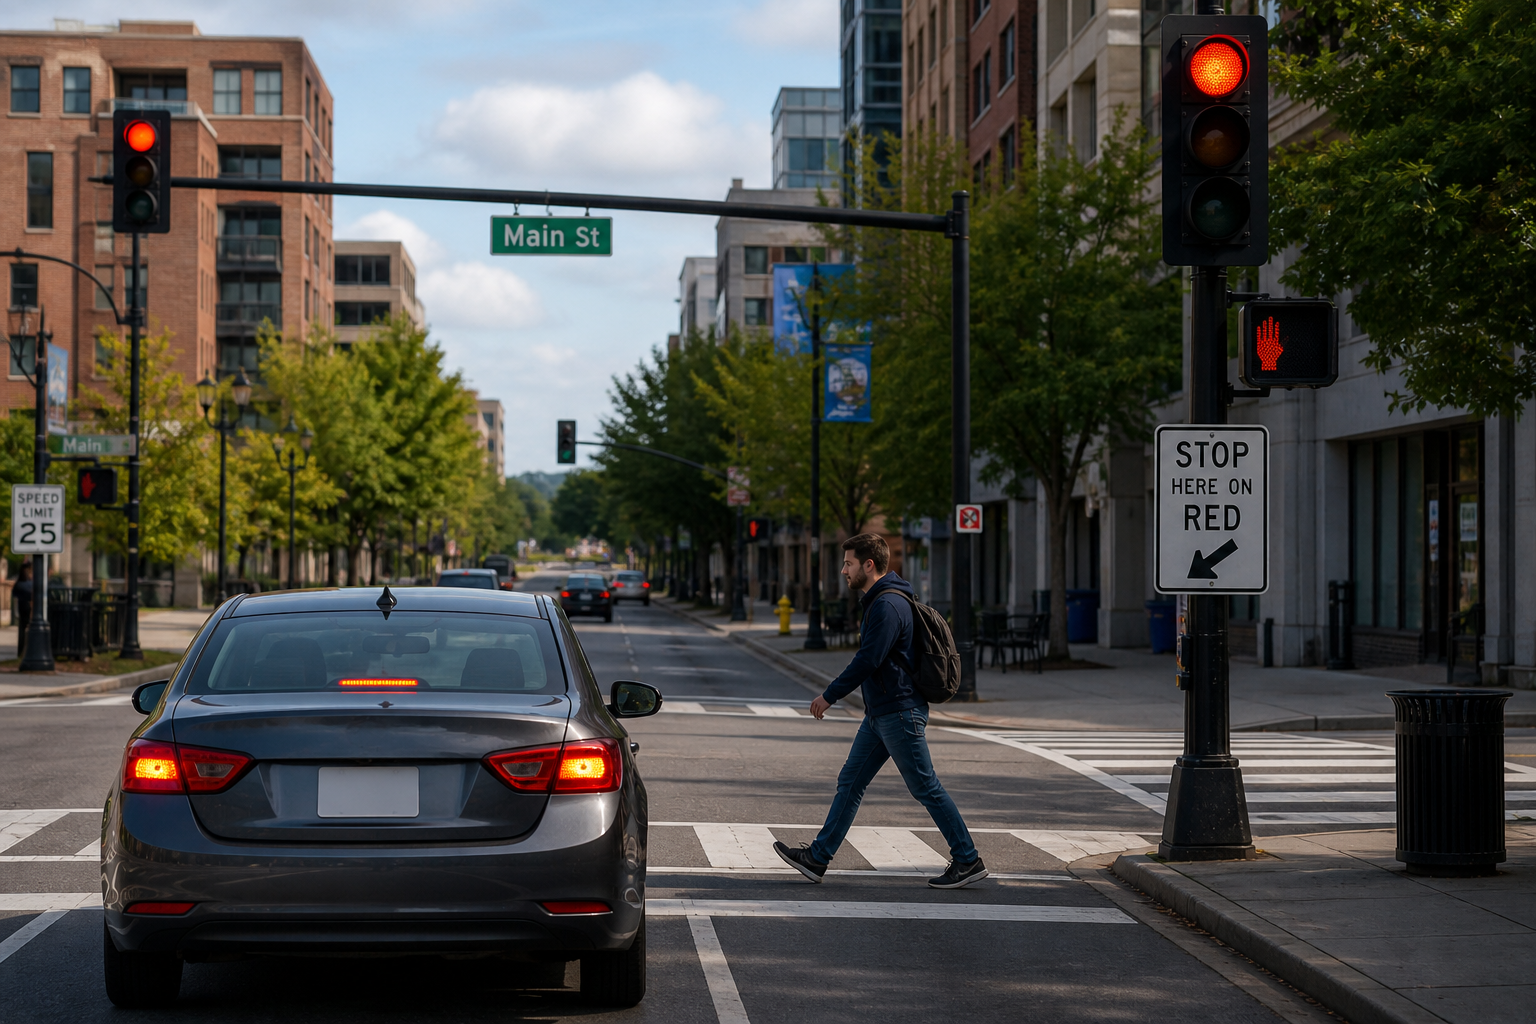

In [9]:
def load_image(path):
    image = Image.open(path).convert('RGB')
    image = ImageOps.exif_transpose(image)
    return image

image_path = 'ViT Image.png'
image = load_image(image_path)

print(f'Image size: {image.size[0]}x{image.size[1]} px')
display(image)

## Task 2: Load Pre-trained YOLOv8 Model

In [10]:
# yolov8n.pt is the nano variant — fast and lightweight, suitable for CPU inference
model = YOLO('yolov8n.pt')
print('Model loaded:', model.info())

YOLOv8n summary: 129 layers, 3,157,200 parameters, 0 gradients, 8.9 GFLOPs
Model loaded: (129, 3157200, 0, 8.8575488)


## Task 3: Perform Inference

In [11]:
results = model(image)

detections = results[0].boxes
print(f'Total objects detected: {len(detections)}')


0: 448x640 1 person, 5 cars, 4 traffic lights, 2 backpacks, 121.4ms
Speed: 3.6ms preprocess, 121.4ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
Total objects detected: 12


## Task 4: Filter and Visualize Specific Classes

We focus on three urban safety categories based on the COCO dataset class IDs:
* **Pedestrians** — person (0)
* **Vehicles** — car (2), motorcycle (3), bus (5), truck (7)
* **Traffic Lights** — traffic light (9)

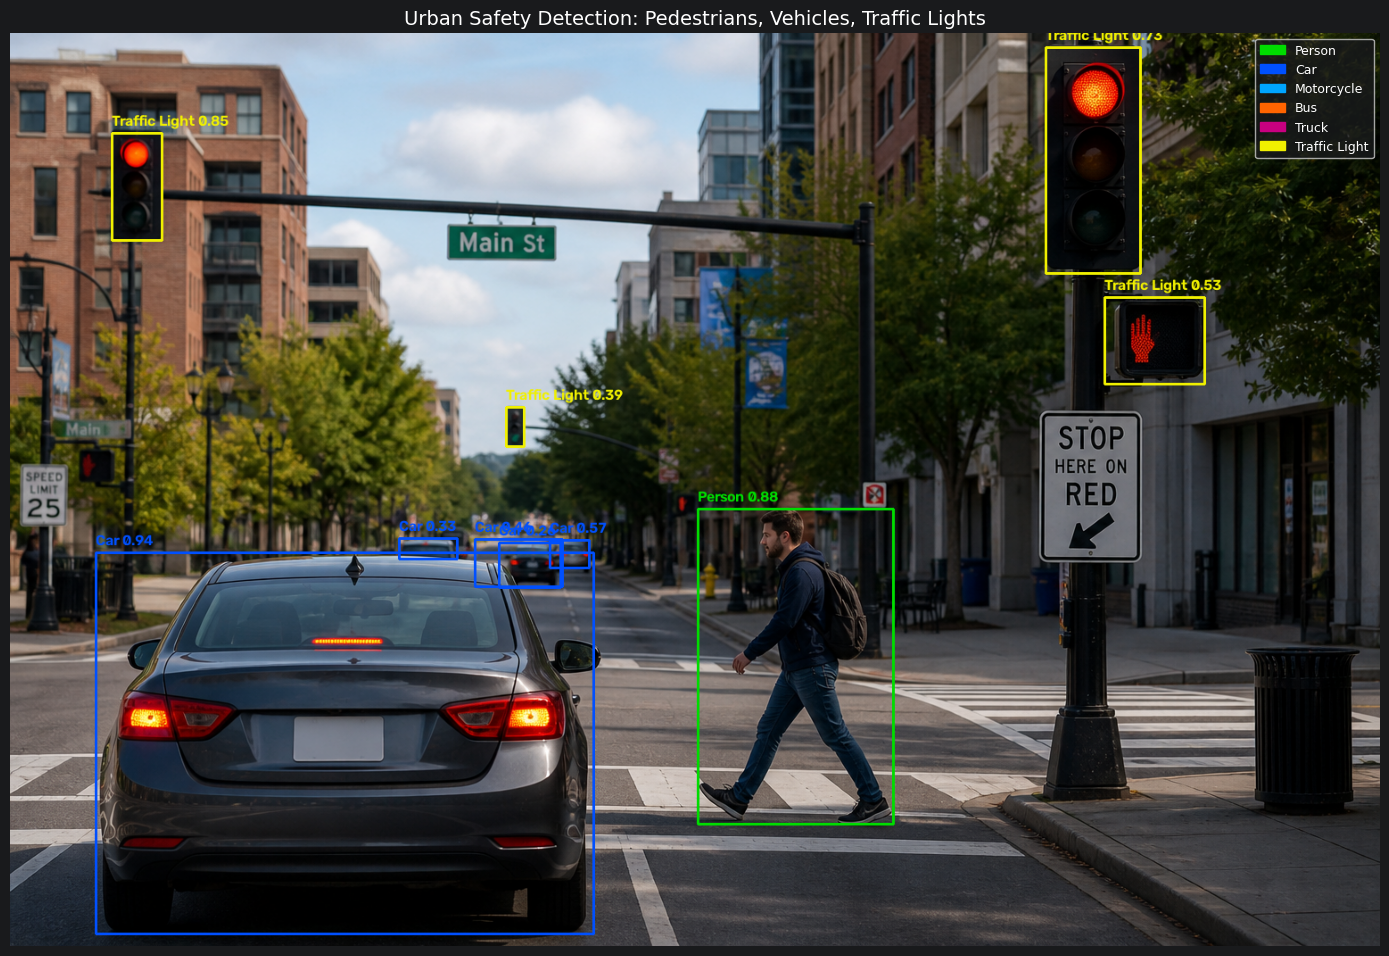


Detection count by class:
Class
Car              5
Traffic Light    4
Person           1


In [12]:
# COCO class IDs mapped to display label and bounding box color (BGR)
target_classes = {
    0: ('Person',        (0,   220,  0)),
    2: ('Car',           (255,  80,  0)),
    3: ('Motorcycle',    (255, 165,  0)),
    5: ('Bus',           (0,   100, 255)),
    7: ('Truck',         (128,   0, 200)),
    9: ('Traffic Light', (0,   240, 240)),
}

# Convert PIL image to BGR for OpenCV drawing
img_bgr = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

filtered_detections = []

for box in detections:
    cls_id = int(box.cls)
    if cls_id not in target_classes:
        continue

    label, color = target_classes[cls_id]
    conf = float(box.conf)
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img_bgr, f'{label} {conf:.2f}', (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)

    filtered_detections.append({'Class': label, 'Confidence': round(conf, 4)})

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Legend
legend_patches = [
    mpatches.Patch(color=tuple(c/255 for c in color[::-1]), label=label)
    for _, (label, color) in target_classes.items()
]

plt.figure(figsize=(14, 10))
plt.imshow(img_rgb)
plt.title('Urban Safety Detection: Pedestrians, Vehicles, Traffic Lights', fontsize=14)
plt.legend(handles=legend_patches, loc='upper right', fontsize=9)
plt.axis('off')
plt.tight_layout()
plt.show()

print('\nDetection count by class:')
df_detected = pd.DataFrame(filtered_detections)
if not df_detected.empty:
    print(df_detected['Class'].value_counts().to_string())
else:
    print('No target-class objects detected in this image.')

## Task 5: Confidence Score Analysis

Confidence scores represent how certain the model is that a detected bounding box contains a specific object class. Scores range from 0 to 1; higher scores indicate stronger predictions.

In [13]:
if df_detected.empty:
    print('No target-class detections to analyze.')
else:
    print('All filtered detections with confidence scores:')
    print(df_detected.sort_values('Confidence', ascending=False).to_string(index=False))

All filtered detections with confidence scores:
        Class  Confidence
          Car      0.9393
       Person      0.8821
Traffic Light      0.8525
Traffic Light      0.7318
          Car      0.5731
Traffic Light      0.5316
          Car      0.4646
Traffic Light      0.3877
          Car      0.3348
          Car      0.2618


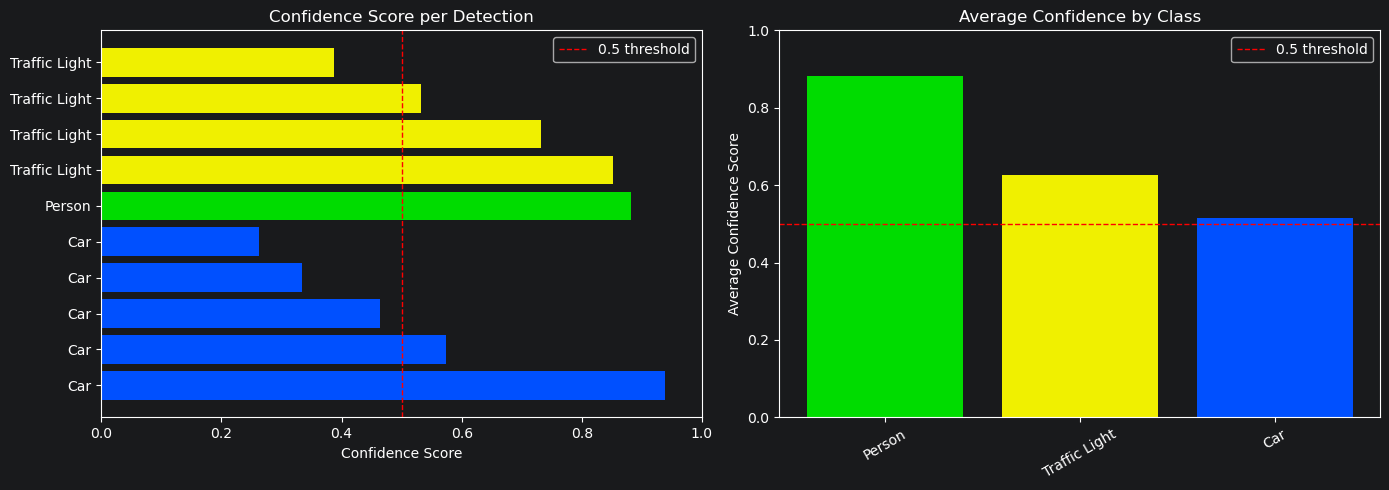


Average confidence by class:
Class
Person           0.8821
Traffic Light    0.6259
Car              0.5147


In [14]:
if not df_detected.empty:
    avg_conf = df_detected.groupby('Class')['Confidence'].mean().sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Individual confidence scores per detection
    df_sorted = df_detected.sort_values(['Class', 'Confidence'], ascending=[True, False]).reset_index(drop=True)
    bar_colors = [
        tuple(c / 255 for c in target_classes[[k for k, (l, _) in target_classes.items() if l == row['Class']][0]][1][::-1])
        for _, row in df_sorted.iterrows()
    ]
    axes[0].barh(df_sorted.index, df_sorted['Confidence'], color=bar_colors)
    axes[0].set_yticks(df_sorted.index)
    axes[0].set_yticklabels(df_sorted['Class'])
    axes[0].set_xlabel('Confidence Score')
    axes[0].set_title('Confidence Score per Detection')
    axes[0].set_xlim(0, 1)
    axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1, label='0.5 threshold')
    axes[0].legend()

    # Average confidence by class
    avg_colors = [
        tuple(c / 255 for c in target_classes[[k for k, (l, _) in target_classes.items() if l == cls][0]][1][::-1])
        for cls in avg_conf.index
    ]
    axes[1].bar(avg_conf.index, avg_conf.values, color=avg_colors)
    axes[1].set_ylabel('Average Confidence Score')
    axes[1].set_title('Average Confidence by Class')
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='0.5 threshold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    print('\nAverage confidence by class:')
    print(avg_conf.round(4).to_string())

## Conclusion

The YOLOv8n model successfully performed real-time object detection on the urban scene image.
Detections were filtered to the three urban safety categories defined by the assignment:
pedestrians, vehicles (car, motorcycle, bus, truck), and traffic lights.

Key observations from the confidence score analysis:
* Detections with scores above 0.5 are considered reliable predictions — the model is confident enough that the identified object belongs to the predicted class.
* Classes with consistently high average confidence indicate that the model recognizes those object types clearly in this scene.
* Low-confidence detections (below 0.5) may correspond to partially occluded or distant objects and should be interpreted with caution.

YOLOv8n (nano) is optimized for speed on CPU, making it a practical baseline for urban safety applications where real-time inference matters more than maximum accuracy.